In [1]:
# import necessary libraries
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# load the pre-trained model and tokenizer
model_name = "SamLowe/roberta-base-go_emotions"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, output_attentions=True
)
model.eval()
print("Model loaded.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded.


In [3]:
# function to get attentions for a given input text
def get_attentions(text):
    inputs = tokenizer(text, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.attentions, tokens

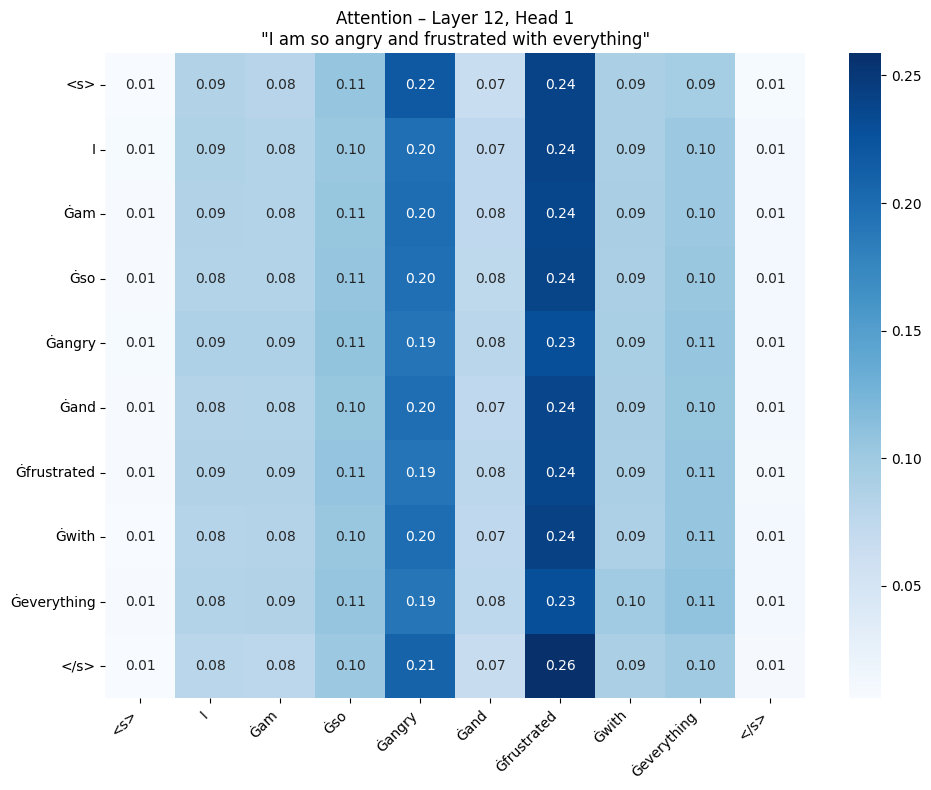

In [4]:
# example text and visualization
text = "I am so angry and frustrated with everything"
attentions, tokens = get_attentions(text)

layer = 11   # last Layer (0-11)
head = 0     # first Head (0-11)
attn = attentions[layer][0, head].numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens,
            cmap="Blues", annot=True, fmt=".2f")
plt.title(f"Attention – Layer {layer+1}, Head {head+1}\n\"{text}\"")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

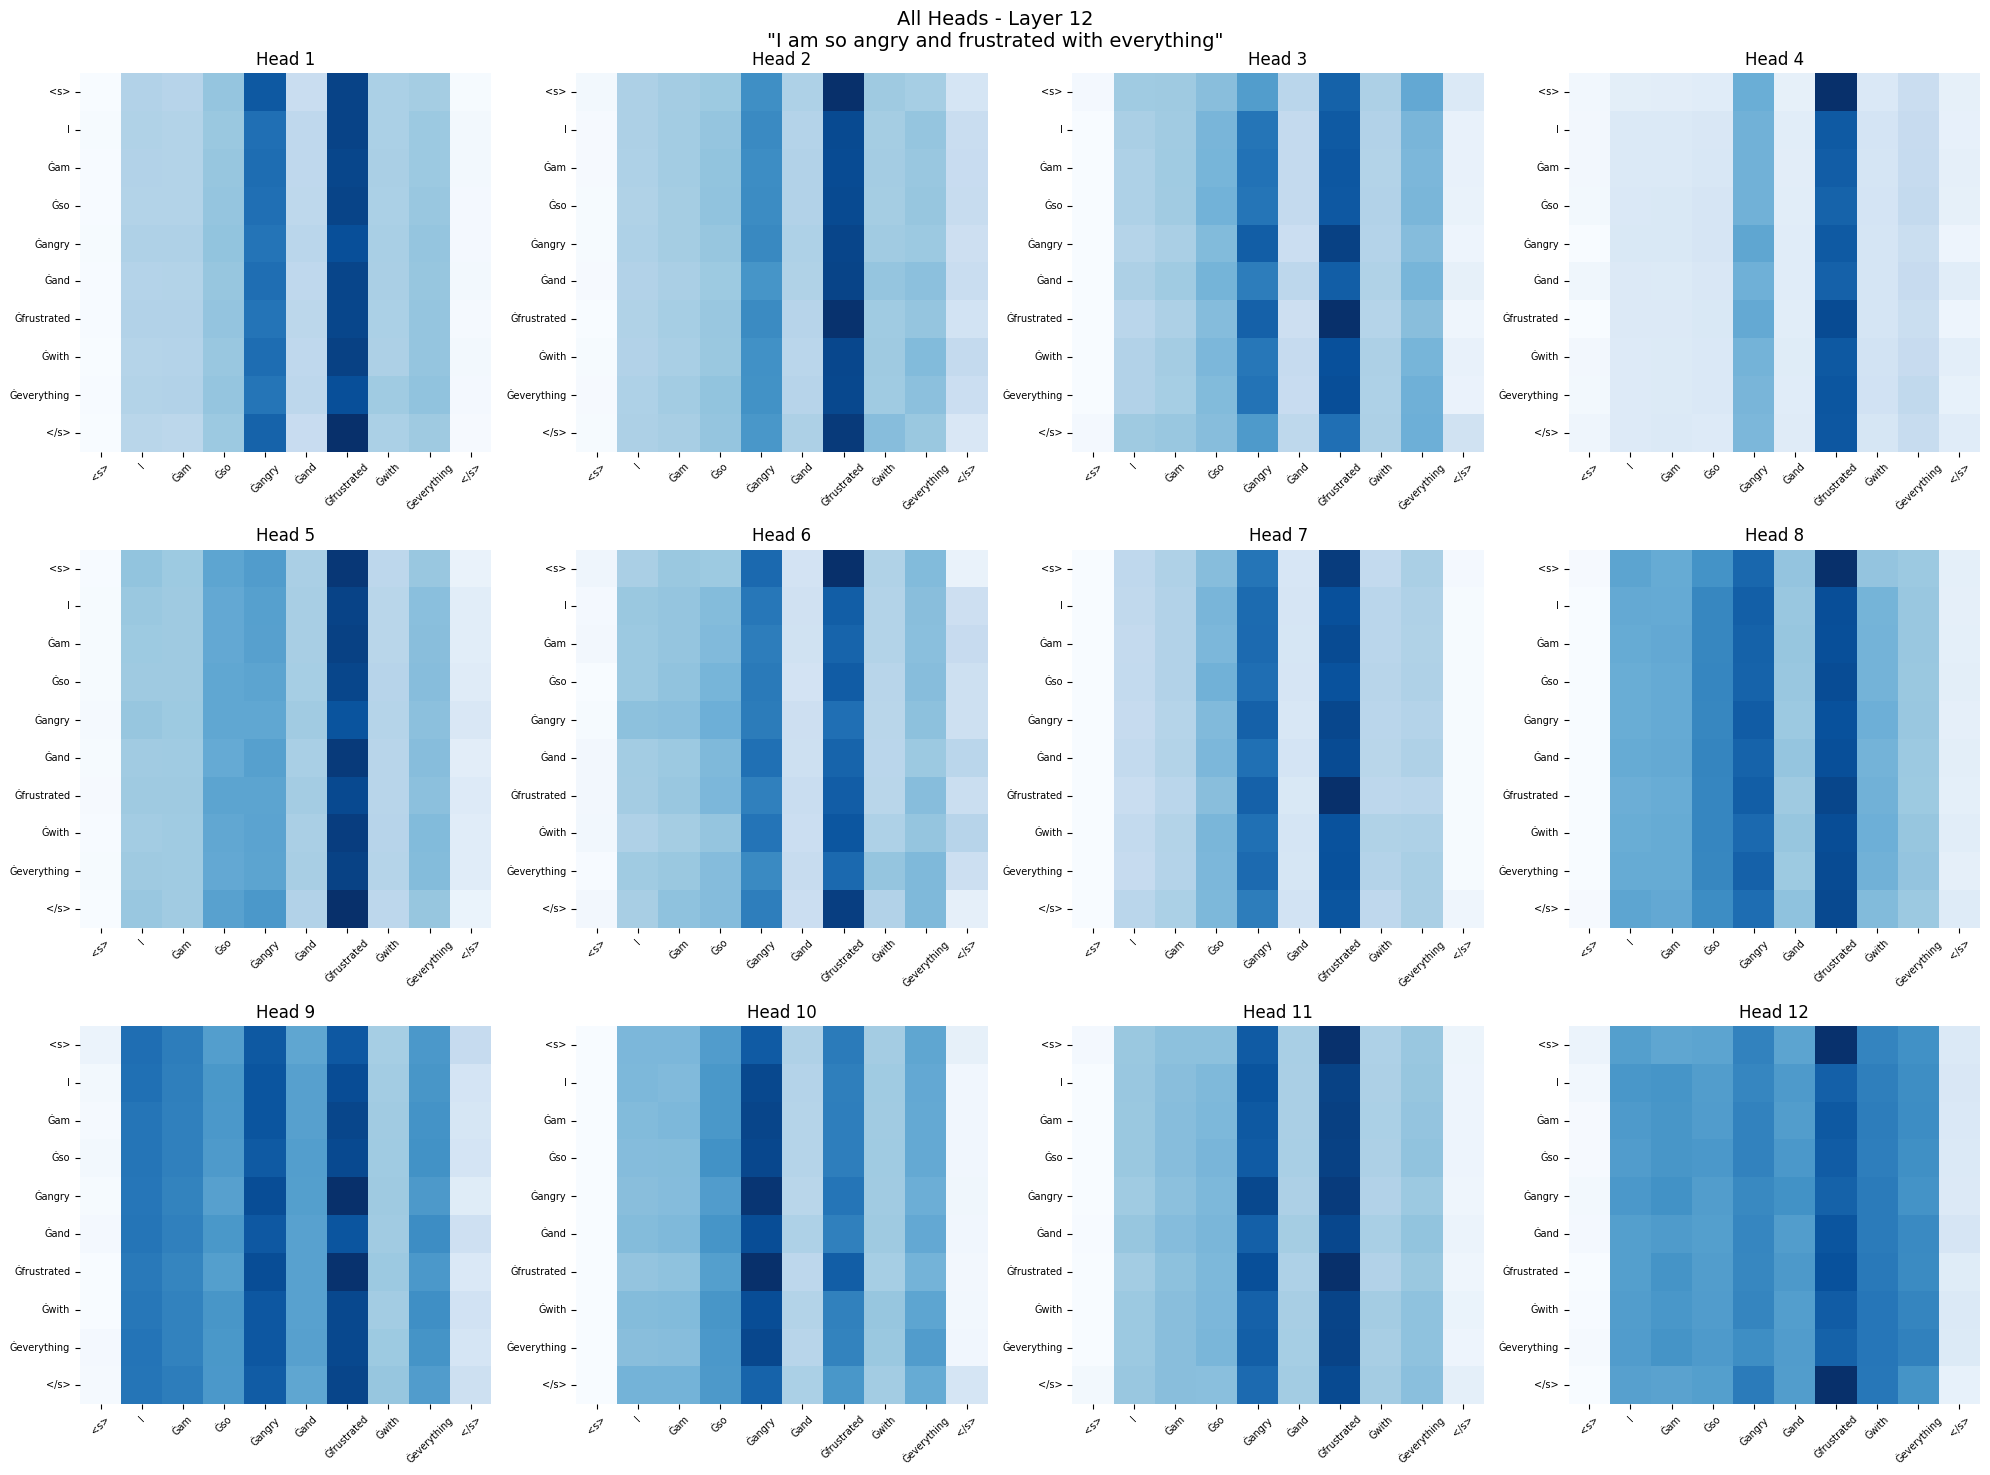

In [5]:
# Visualize all heads in the last layer
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for h in range(12):
    attn = attentions[layer][0, h].numpy()
    sns.heatmap(attn, xticklabels=tokens, yticklabels=tokens,
                cmap="Blues", ax=axes[h], cbar=False)
    axes[h].set_title(f"Head {h+1}")
    axes[h].tick_params(axis='x', rotation=45, labelsize=7)
    axes[h].tick_params(axis='y', labelsize=7)

plt.suptitle(f"All Heads - Layer {layer+1}\n\"{text}\"", fontsize=14)
plt.tight_layout()
plt.show()

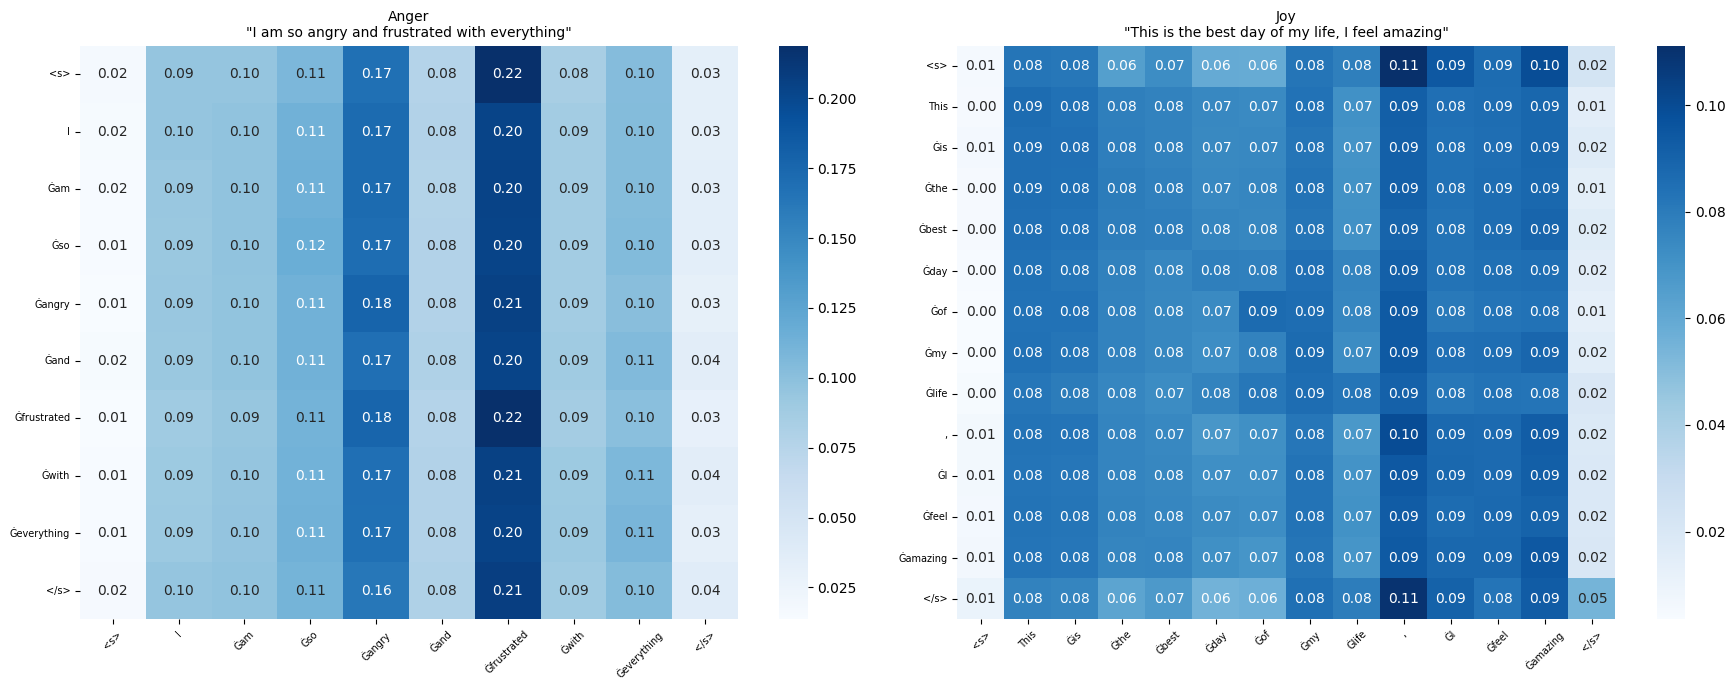

In [6]:
# Compare attention patterns for different sentences
sentences = {
    "Anger": "I am so angry and frustrated with everything",
    "Joy":   "This is the best day of my life, I feel amazing"
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (emotion, sent) in zip(axes, sentences.items()):
    atts, toks = get_attentions(sent)
    attn_mean = atts[11][0].mean(dim=0).numpy()  # Durchschnitt über alle Heads
    sns.heatmap(attn_mean, xticklabels=toks, yticklabels=toks,
                cmap="Blues", ax=ax, annot=True, fmt=".2f")
    ax.set_title(f"{emotion}\n\"{sent}\"", fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()

In [ ]:
# Compare attention patterns for Negation and Sarcasm sentences
error_sentences = {
    "Negation": "I am not happy about this development",
    "Sarcasm":  "Oh great, another delay"
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (error_type, sent) in zip(axes, error_sentences.items()):
    atts, toks = get_attentions(sent)
    attn_mean = atts[11][0].mean(dim=0).numpy()  # Average over all heads in Layer 12
    sns.heatmap(attn_mean, xticklabels=toks, yticklabels=toks,
                cmap="Blues", ax=ax, annot=True, fmt=".2f")
    ax.set_title(f"{error_type}\n\"{sent}\"", fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.show()